# Task 3 - HSBC CreditLens: Jurisdiction-Aware AI Credit Scoring Compliance Tool

This notebook implements a small synthetic-data prototype for a jurisdiction-aware RegTech tool. It compares how the same AI-assisted credit scoring output would be monitored under a US fair lending / Regulation B lens and a Hong Kong AI governance lens.

## Design logic

- **Entity**: HSBC, with US and Hong Kong operations.
- **Domain**: AI-assisted credit scoring and model governance.
- **US mode**: fair lending metrics, adverse impact ratio, and adverse-action reasons.
- **Hong Kong mode**: AI governance, human oversight, proportionality, privacy, and consumer credit data controls.
- **Data**: synthetic applicants only; no HSBC customer data is used.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
DATA_PATH = Path('Task3_synthetic_credit_data.csv')
OUTPUT_DIR = Path('Task3_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(6000, 13)


,applicant_id,jurisdiction,protected_group,annual_income,debt_to_income,credit_utilization,credit_history_months,delinquencies_24m,recent_inquiries,age,employment_stable,existing_hsbc_customer,default_12m
0,A00001,US,comparison_group,31285,0.193,0.854,13,0,2,42,0,1,0
1,A00002,HK,reference_group,172356,0.255,0.169,29,0,1,38,1,0,0
2,A00003,US,comparison_group,75640,0.154,0.425,6,1,1,53,1,0,0
3,A00004,HK,reference_group,53015,0.510,0.243,69,0,1,59,1,1,0
4,A00005,US,reference_group,44190,0.382,0.195,131,0,0,21,1,1,0


## Jurisdiction configuration layer

The configuration layer is the core of the jurisdiction-aware design. It changes thresholds, required evidence, and output templates without changing the model itself.

In [3]:
JURISDICTION_RULES = {
    'US': {
        'regulatory_focus': 'ECOA / Regulation B fair lending and adverse-action notices',
        'approval_disparity_floor': 0.80,
        'equal_opportunity_gap_limit': 0.05,
        'requires_adverse_action_reasons': True,
        'requires_human_review_band': True,
        'human_review_pd_band': (0.30, 0.38),
        'output': 'specific principal denial reasons and fair-lending alert'
    },
    'HK': {
        'regulatory_focus': 'HKMA AI governance, proportionality, consumer credit data and privacy controls',
        'approval_disparity_floor': 0.85,
        'equal_opportunity_gap_limit': 0.08,
        'requires_adverse_action_reasons': False,
        'requires_human_review_band': True,
        'human_review_pd_band': (0.28, 0.40),
        'output': 'governance evidence, validation status and human oversight trigger'
    }
}
pd.DataFrame(JURISDICTION_RULES).T

,regulatory_focus,approval_disparity_floor,equal_opportunity_gap_limit,requires_adverse_action_reasons,requires_human_review_band,human_review_pd_band,output
US,ECOA / Regulation B fair lending and adverse-a...,0.800,0.050,True,True,"(0.3, 0.38)",specific principal denial reasons and fair-len...
HK,"HKMA AI governance, proportionality, consumer ...",0.850,0.080,False,True,"(0.28, 0.4)","governance evidence, validation status and hum..."


## Train a transparent credit risk model

In [4]:
features = ['annual_income', 'debt_to_income', 'credit_utilization', 'credit_history_months',
            'delinquencies_24m', 'recent_inquiries', 'age', 'employment_stable', 'existing_hsbc_customer']
X = df[features]
y = df['default_12m']
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.32, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
model = LogisticRegression(max_iter=1500, class_weight='balanced', random_state=42)
model.fit(X_train_s, y_train)
pred_pd = model.predict_proba(X_test_s)[:, 1]
auc = roc_auc_score(y_test, pred_pd)
print(f'AUC: {auc:.3f}')
coef = pd.Series(model.coef_[0], index=features).sort_values(key=np.abs, ascending=False)
coef

AUC: 0.671


annual_income            -0.509
debt_to_income            0.379
credit_utilization        0.264
recent_inquiries          0.173
credit_history_months    -0.144
delinquencies_24m         0.143
employment_stable        -0.101
existing_hsbc_customer   -0.072
age                      -0.068
dtype: float64

In [5]:
scored = df.loc[idx_test].copy()
scored['predicted_pd'] = pred_pd
scored['approved'] = (scored['predicted_pd'] < 0.34).astype(int)
scored['human_review'] = scored.apply(
    lambda r: JURISDICTION_RULES[r['jurisdiction']]['human_review_pd_band'][0] <= r['predicted_pd'] <= JURISDICTION_RULES[r['jurisdiction']]['human_review_pd_band'][1],
    axis=1
)
scored[['jurisdiction','protected_group','predicted_pd','approved','human_review']].head()

,jurisdiction,protected_group,predicted_pd,approved,human_review
1431,US,reference_group,0.538,0,False
5210,US,reference_group,0.429,0,False
4841,US,reference_group,0.074,1,False
5680,US,comparison_group,0.222,1,False
4029,US,reference_group,0.301,1,True


## Fairness metrics by jurisdiction

In [6]:
def group_metrics(frame):
    rows = []
    for group, part in frame.groupby('protected_group'):
        approved = part['approved'] == 1
        actual_good = part['default_12m'] == 0
        actual_bad = part['default_12m'] == 1
        rows.append({
            'protected_group': group,
            'n': len(part),
            'approval_rate': approved.mean(),
            'false_negative_rate': ((part['approved'] == 1) & actual_bad).sum() / max(actual_bad.sum(), 1),
            'false_positive_rate': ((part['approved'] == 0) & actual_good).sum() / max(actual_good.sum(), 1),
            'true_positive_rate_good': ((part['approved'] == 1) & actual_good).sum() / max(actual_good.sum(), 1),
        })
    return pd.DataFrame(rows)

def jurisdiction_report(scored, jurisdiction):
    rules = JURISDICTION_RULES[jurisdiction]
    gm = group_metrics(scored[scored['jurisdiction'] == jurisdiction])
    ref = gm.loc[gm['protected_group'] == 'reference_group'].iloc[0]
    comp = gm.loc[gm['protected_group'] == 'comparison_group'].iloc[0]
    adverse_impact_ratio = comp['approval_rate'] / ref['approval_rate']
    eq_opp_diff = comp['true_positive_rate_good'] - ref['true_positive_rate_good']
    return {
        'jurisdiction': jurisdiction,
        'regulatory_focus': rules['regulatory_focus'],
        'adverse_impact_ratio': adverse_impact_ratio,
        'equal_opportunity_diff': eq_opp_diff,
        'flag_disparity': adverse_impact_ratio < rules['approval_disparity_floor'],
        'flag_equal_opportunity': abs(eq_opp_diff) > rules['equal_opportunity_gap_limit'],
        'human_review_rate': scored.loc[scored['jurisdiction'] == jurisdiction, 'human_review'].mean(),
        'group_metrics': gm
    }

reports = {jur: jurisdiction_report(scored, jur) for jur in ['US', 'HK']}
summary = pd.DataFrame([{k:v for k,v in r.items() if k != 'group_metrics'} for r in reports.values()])
summary

,jurisdiction,regulatory_focus,adverse_impact_ratio,equal_opportunity_diff,flag_disparity,flag_equal_opportunity,human_review_rate
0,US,ECOA / Regulation B fair lending and adverse-a...,0.571,-0.115,True,True,0.148
1,HK,"HKMA AI governance, proportionality, consumer ...",0.539,-0.168,True,True,0.250


In [7]:
for jur, report in reports.items():
    print('\n' + jur)
    display(report['group_metrics'])


US


,protected_group,n,approval_rate,false_negative_rate,false_positive_rate,true_positive_rate_good
0,comparison_group,260,0.150,0.071,0.846,0.154
1,reference_group,643,0.263,0.053,0.731,0.269



HK


,protected_group,n,approval_rate,false_negative_rate,false_positive_rate,true_positive_rate_good
0,comparison_group,272,0.180,0.192,0.821,0.179
1,reference_group,745,0.334,0.103,0.653,0.347


## Jurisdiction-specific output

In [8]:
reason_labels = {
    'annual_income': 'Income level was low relative to requested risk profile',
    'debt_to_income': 'Debt-to-income ratio was high',
    'credit_utilization': 'Credit utilization was high',
    'credit_history_months': 'Credit history was limited',
    'delinquencies_24m': 'Recent delinquency history increased risk',
    'recent_inquiries': 'Recent credit inquiries increased risk',
    'age': 'Age-related feature contribution requires compliance review before use',
    'employment_stable': 'Employment stability indicator reduced confidence',
    'existing_hsbc_customer': 'Limited existing relationship evidence'
}

def adverse_action_reasons(row, top_n=3):
    row_s = scaler.transform(row[features].to_frame().T)[0]
    contributions = pd.Series(row_s * model.coef_[0], index=features).sort_values(ascending=False)
    return [reason_labels[f] for f in contributions.head(top_n).index]

def compliance_output(row):
    rules = JURISDICTION_RULES[row['jurisdiction']]
    base = {
        'applicant_id': row['applicant_id'],
        'jurisdiction': row['jurisdiction'],
        'approved': bool(row['approved']),
        'predicted_pd': round(float(row['predicted_pd']), 3),
        'human_review': bool(row['human_review']),
        'regulatory_focus': rules['regulatory_focus'],
    }
    if row['jurisdiction'] == 'US' and row['approved'] == 0:
        base['adverse_action_reasons'] = adverse_action_reasons(row)
        base['required_output'] = 'specific principal denial reasons plus fair-lending metric check'
    elif row['jurisdiction'] == 'HK':
        base['required_output'] = 'AI governance evidence, proportional human oversight and privacy/data controls'
        base['governance_controls'] = ['model validation evidence', 'human review band', 'privacy impact assessment', 'monthly outcome monitoring']
    return base

examples = scored.groupby('jurisdiction').apply(lambda x: x[x['approved']==0].head(1)).reset_index(drop=True)
[compliance_output(row) for _, row in examples.iterrows()]

[{'applicant_id': 'A04523',
  'jurisdiction': 'HK',
  'approved': False,
  'predicted_pd': 0.694,
  'human_review': False,
  'regulatory_focus': 'HKMA AI governance, proportionality, consumer credit data and privacy controls',
  'required_output': 'AI governance evidence, proportional human oversight and privacy/data controls',
  'governance_controls': ['model validation evidence',
   'human review band',
   'privacy impact assessment',
   'monthly outcome monitoring']},
 {'applicant_id': 'A01432',
  'jurisdiction': 'US',
  'approved': False,
  'predicted_pd': 0.538,
  'human_review': False,
  'regulatory_focus': 'ECOA / Regulation B fair lending and adverse-action notices',
  'adverse_action_reasons': ['Income level was low relative to requested risk profile',
   'Recent credit inquiries increased risk',
   'Recent delinquency history increased risk'],
  'required_output': 'specific principal denial reasons plus fair-lending metric check'}]

## Drift sensitivity analysis

In [9]:
def adverse_impact_after_shift(delta):
    shifted = scored.copy()
    shifted['predicted_pd'] = np.clip(shifted['predicted_pd'] + delta, 0, 1)
    shifted['approved'] = (shifted['predicted_pd'] < 0.34).astype(int)
    out = {}
    for jur in ['US', 'HK']:
        gm = group_metrics(shifted[shifted['jurisdiction'] == jur])
        ref = gm.loc[gm['protected_group'] == 'reference_group', 'approval_rate'].iloc[0]
        comp = gm.loc[gm['protected_group'] == 'comparison_group', 'approval_rate'].iloc[0]
        out[jur] = comp / ref
    return out

sensitivity = pd.DataFrame([{'pd_shift': d, **adverse_impact_after_shift(d)} for d in [-0.05,-0.025,0,0.025,0.05,0.075]])
sensitivity

,pd_shift,US,HK
0,-0.050,0.537,0.559
1,-0.025,0.550,0.539
2,0.000,0.571,0.539
3,0.025,0.550,0.454
4,0.050,0.601,0.400
5,0.075,0.543,0.386


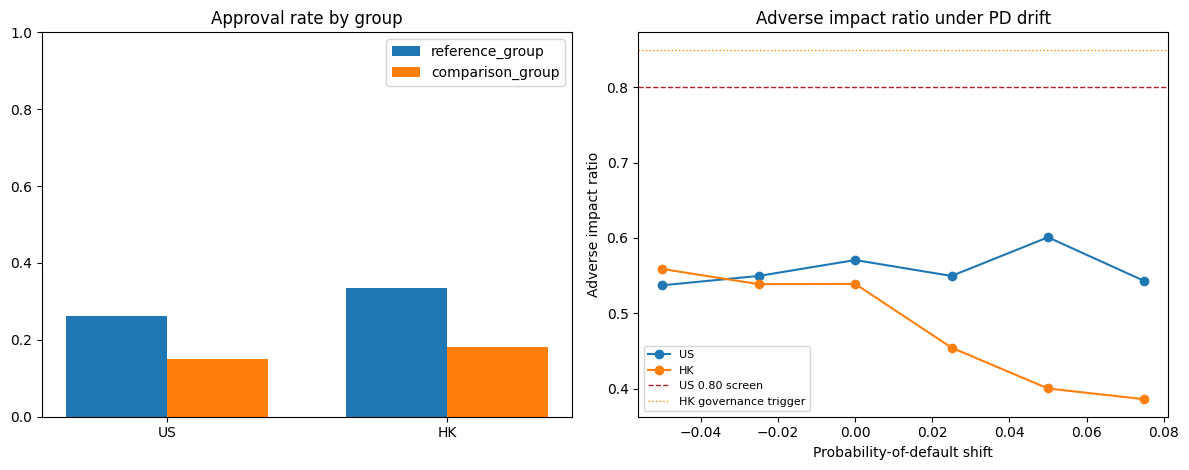

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_data = []
for jur in ['US', 'HK']:
    gm = reports[jur]['group_metrics'].copy()
    gm['jurisdiction'] = jur
    plot_data.append(gm)
plot_data = pd.concat(plot_data)
x = np.arange(2)
width = 0.36
for i, group in enumerate(['reference_group', 'comparison_group']):
    vals = [plot_data[(plot_data['jurisdiction']==jur) & (plot_data['protected_group']==group)]['approval_rate'].iloc[0] for jur in ['US','HK']]
    axes[0].bar(x + (i-0.5)*width, vals, width, label=group)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['US','HK'])
axes[0].set_ylim(0, 1)
axes[0].set_title('Approval rate by group')
axes[0].legend()
for jur in ['US','HK']:
    axes[1].plot(sensitivity['pd_shift'], sensitivity[jur], marker='o', label=jur)
axes[1].axhline(0.80, color='firebrick', linestyle='--', linewidth=1, label='US 0.80 screen')
axes[1].axhline(0.85, color='darkorange', linestyle=':', linewidth=1, label='HK governance trigger')
axes[1].set_title('Adverse impact ratio under PD drift')
axes[1].set_xlabel('Probability-of-default shift')
axes[1].set_ylabel('Adverse impact ratio')
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fairness_and_drift_dashboard.png', dpi=160, bbox_inches='tight')
plt.show()

## Management interpretation

The prototype demonstrates that the tool is not just a spreadsheet of rules. The jurisdiction configuration changes what the same model output means. In the US, a denied applicant requires specific principal reasons and fair-lending screening. In Hong Kong, the same score is framed as AI governance evidence requiring validation, proportionality, human oversight, and privacy/data controls.

In [11]:
export = {
    'auc': float(auc),
    'summary': summary.to_dict(orient='records'),
    'sensitivity': sensitivity.to_dict(orient='records')
}
with open(OUTPUT_DIR / 'notebook_metrics_export.json', 'w') as f:
    json.dump(export, f, indent=2)
print('Exported metrics to', OUTPUT_DIR / 'notebook_metrics_export.json')

Exported metrics to Task3_outputs/notebook_metrics_export.json
